In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
import io

print("All libraries downloaded successfully!!")

All libraries downloaded successfully!!


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving GermanCredit.csv to GermanCredit.csv


In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['GermanCredit.csv']))

In [ ]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [ ]:
df.describe()

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.700000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

**PROBLEM FORMULATION**


In [ ]:
"""
Business Background:
-------------------
Banks face significant financial losses when borrowers default on loans.
Approving credit to high-risk customers results in direct financial loss,
while rejecting good customers means lost revenue opportunities.

The German Credit dataset contains 1,000 loan applicants classified as
good (0) or bad (1) credit risks based on 20 attributes.

Business Metrics:
- False Negative (missed bad customer → bank loses money)
- False Positive (rejected good customer → bank loses revenue)
- Cost of misclassification: missing a bad customer is 5x more costly
  than rejecting a good one (based on UCI cost matrix)

ML Problem Framing:
-------------------
Binary Classification → predict credit_risk (0 = good, 1 = bad)
"""

print("Dataset loaded successfully!!")
print(f"Total customers: {len(df)}")
print(f"Good credit(0): {(df['credit_risk'] == 0).sum()}")
print(f"Bad credit(1): {(df['credit_risk'] == 1).sum()}")
print(f"Default rate: {(df['credit_risk'] == 1).mean()*100:.1f}%")

Dataset loaded successfully!!
Total customers: 1000
Good credit(0): 300
Bad credit(1): 700
Default rate: 70.0%


In [ ]:
#check first few rows to understand the label meaning
df[['status', 'credit_history', 'amount', 'credit_risk']].head(10)

,status,credit_history,amount,credit_risk
0,... < 100 DM,critical account/other credits existing,1169,1
1,0 <= ... < 200 DM,existing credits paid back duly till now,5951,0
2,no checking account,critical account/other credits existing,2096,1
3,... < 100 DM,existing credits paid back duly till now,7882,1
4,... < 100 DM,delay in paying off in the past,4870,0
5,no checking account,existing credits paid back duly till now,9055,1
6,no checking account,existing credits paid back duly till now,2835,1
7,0 <= ... < 200 DM,existing credits paid back duly till now,6948,1
8,no checking account,existing credits paid back duly till now,3059,1
9,0 <= ... < 200 DM,critical account/other credits existing,5234,0


In [ ]:
print("\nValue counts:")
print(df['credit_risk'].value_counts())


Value counts:
credit_risk
1    700
0    300
Name: count, dtype: int64


In [ ]:
#label verification
# 1 = Bad credit risk (high default probability)
# 0 = Good credit risk (low default probability)
# Distribution: 700 bad (70%), 300 good (30%)
# Note: This is an imbalanced dataset - we will handle this during modeling

print("Label verified - no changes needed")
print(f"\nClass distribution:")
print(f"Bad credit (1): 700 (70%)")
print(f"Good credit (0): 300 (30%)")

Label verified - no changes needed

Class distribution:
Bad credit (1): 700 (70%)
Good credit (0): 300 (30%)


**EXPLORATORY DATA ANALYSIS **

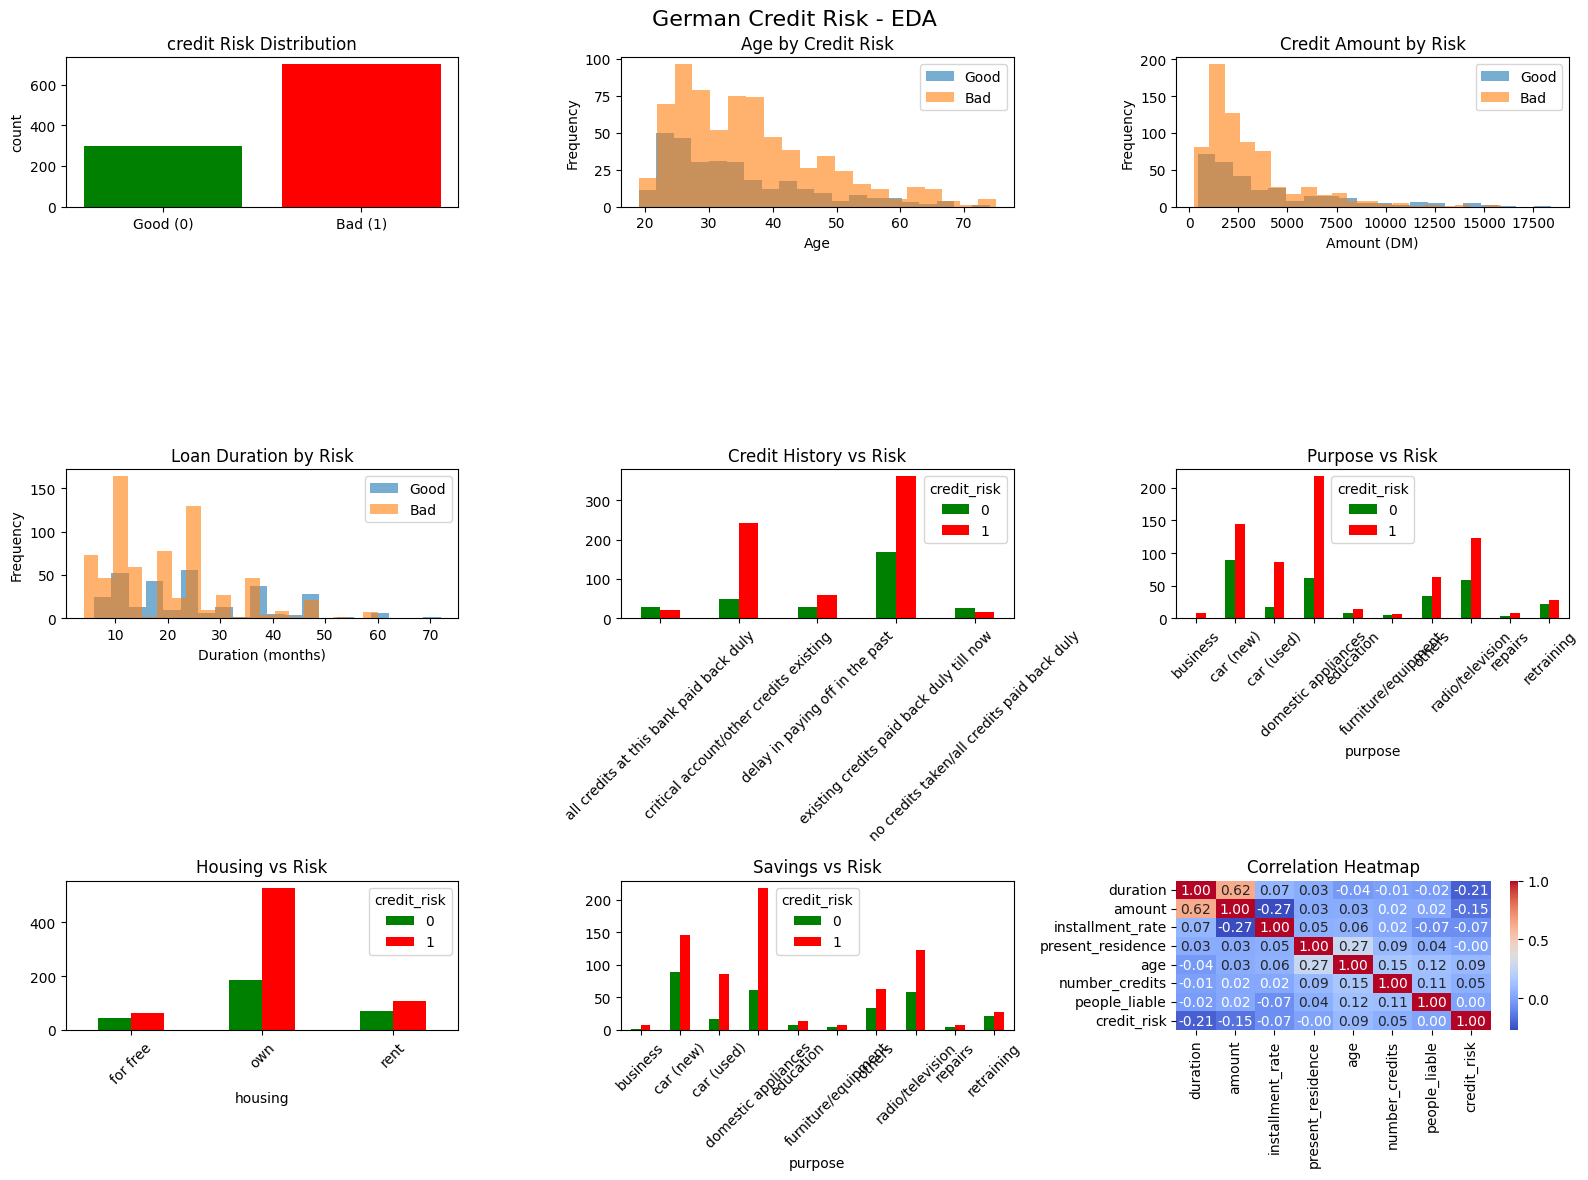

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('German Credit Risk - EDA', fontsize=16)

# 1. Target distribution
axes[0, 0].bar(['Good (0)', 'Bad (1)'],
               [df['credit_risk'].value_counts()[0], df['credit_risk'].value_counts()[1]],
               color=['green', 'red'])
axes[0,0].set_title('credit Risk Distribution')
axes[0,0].set_ylabel('count')

# 2. Age distribution
df.groupby('credit_risk')['age'].plot(kind='hist', alpha=0.6, bins=20, ax=axes[0,1])
axes[0,1].set_title('Age by Credit Risk')
axes[0,1].set_xlabel('Age')
axes[0,1].legend(['Good', 'Bad'])

# 3. Credit amount distribution
df.groupby('credit_risk')['amount'].plot(kind='hist', alpha=0.6, bins=20, ax=axes[0,2])
axes[0,2].set_title('Credit Amount by Risk')
axes[0,2].set_xlabel('Amount (DM)')
axes[0,2].legend(['Good', 'Bad'])

# 4. Duration distribution
df.groupby('credit_risk')['duration'].plot(kind='hist', alpha=0.6, bins=20, ax=axes[1,0])
axes[1,0].set_title('Loan Duration by Risk')
axes[1,0].set_xlabel('Duration (months)')
axes[1,0].legend(['Good', 'Bad'])

# 5. Credit history vs risk
credit_hist = df.groupby(['credit_history', 'credit_risk']).size().unstack()
credit_hist.plot(kind="bar", ax=axes[1,1], color=['green', 'red'])
axes[1,1].set_title('Credit History vs Risk')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Purpose vs risk
purpose = df.groupby(['purpose', 'credit_risk']).size().unstack()
purpose.plot(kind="bar", ax=axes[1,2], color=['green', 'red'])
axes[1,2].set_title('Purpose vs Risk')
axes[1,2].tick_params(axis='x', rotation=45)

#7. Housing vs risk
history = df.groupby(['housing', 'credit_risk']).size().unstack()
history.plot(kind="bar", ax=axes[2,0], color=['green', 'red'])
axes[2,0].set_title('Housing vs Risk')
axes[2,0].tick_params(axis='x', rotation=45)

#8. Savings vs risk
savings = df.groupby(['savings', 'credit_risk']).size().unstack()
purpose.plot(kind="bar", ax=axes[2,1], color=['green', 'red'])
axes[2,1].set_title('Savings vs Risk')
axes[2,1].tick_params(axis='x', rotation=45)

#9. Correlation Heatmap (numeric only)
numeric_cols = df.select_dtypes(include='number').columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt = '.2f',
            cmap="coolwarm", ax=axes[2,2])
axes[2,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

**EDA SUMMARY**

In [ ]:
print("Key EDA Findings:")
print("="*50)
print(f"1. Imbalanced dataset: 70% bad, 30% good credit")
print(f"2. Younger borrowers (20-30) are higher risk")
print(f"3. Low savings strongly associated with bad credit")
print(f"4. Duration & amount are correlated (0.62)")
print(f"5. Categorical features ikely carry more signal")
print(f"\nNext Step: Data Preprocessing")

Key EDA Findings:
1. Imbalanced dataset: 70% bad, 30% good credit
2. Younger borrowers (20-30) are higher risk
3. Low savings strongly associated with bad credit
4. Duration & amount are correlated (0.62)
5. Categorical features ikely carry more signal

Next Step: Data Preprocessing


**3. DATA PREPROCESSING**

In [ ]:
# --- 3.1 Separate features and target ---
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

# --- 3.2 Identify categorical and numerical columns ---
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# --- 3.3 Encode categorical columns ---
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_encoded = X.copy()

for col in cat_cols:
  X_encoded[col] = le.fit_transform(X_encoded[col])

print("\nAfter encoding, shape:", X_encoded.shape)
print(X_encoded.head())

# --- 3.4 Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # keep same class ratio in both sets
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Categorical columns: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Numerical columns: ['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable']

After encoding, shape: (1000, 20)
   status  duration  credit_history  purpose  amount  savings  \
0       0         6               1        3    1169        4   
1       2        48               3        3    5951        0   
2       3        12               1        9    2096        0   
3       0        42               3        7    7882        0   
4       0        24               2        1    4870        0   

   employment_duration  installment_rate  personal_status_sex  other_debtors  \
0                    1                 4                    3              2   
1                    2                 2                    0     

**4. MODELING**

In [ ]:
# --- 4.1 Baseline Model: Logistic Regression ---
lr_model = LogisticRegression(
    class_weight='balanced', #handles imbalance
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("BASELINE MODEL: Logistic Regression")
print("="*50)
print(classification_report(y_test, lr_pred,
      target_names=['Good Credit', 'Bad Credit']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]):.4f}")

# --- 4.2 Main Model: XGBoost ---
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=560/240,  # handles imbalance (bad/good ratio)
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("\nMAIN MODEL: XGBoost")
print("="*50)
print(classification_report(y_test, xgb_pred,
      target_names=['Good Credit', 'Bad Credit']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")

BASELINE MODEL: Logistic Regression
              precision    recall  f1-score   support

 Good Credit       0.49      0.72      0.59        60
  Bad Credit       0.85      0.69      0.76       140

    accuracy                           0.69       200
   macro avg       0.67      0.70      0.67       200
weighted avg       0.74      0.69      0.71       200

ROC-AUC Score: 0.7598

MAIN MODEL: XGBoost
              precision    recall  f1-score   support

 Good Credit       0.62      0.40      0.48        60
  Bad Credit       0.78      0.89      0.83       140

    accuracy                           0.74       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.73      0.74      0.73       200

ROC-AUC Score: 0.7896


**5. HYPERPARAMETER TUNING**


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_tuned = xgb.XGBClassifier(
    scale_pos_weight=560/240,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_grid,
    n_iter=20, #tries 20 random combinations
    scoring='roc_auc', #optimize for ROC-AUC
    cv=5, #5-fold cross validation
    random_state=42,
    n_jobs=-1 #use all CPU cores
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

# Evaluate best model on test set
best_model = search.best_estimator_
best_pred = best_model.predict(X_test)

print("\nTUNED XGBoost")
print("="*50)
print(classification_report(y_test, best_pred,
      target_names=['Good Credit', 'Bad Credit']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]):.4f}")

Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.7965

TUNED XGBoost
              precision    recall  f1-score   support

 Good Credit       0.68      0.25      0.37        60
  Bad Credit       0.75      0.95      0.84       140

    accuracy                           0.74       200
   macro avg       0.71      0.60      0.60       200
weighted avg       0.73      0.74      0.70       200

ROC-AUC Score: 0.7615


**6. BUSINESS IMPACT ANALYSIS**

In [ ]:
#UCI Cost Matrix
# Misclassifying Bad as Good (False Negative) = cost of 5
#Misclassifying Good as Bad (False Positive) = cost of 1

from sklearn.metrics import confusion_matrix

#We use default xgboost as as final model (best ROC-AUC)
cm = confusion_matrix(y_test, xgb_pred)

TN = cm[0,0] #Good predicted as good
FP = cm[0,1] #Good predicted as bad
FN = cm[1,0] #Bad predicted as good <- dangerous
TP = cm[1,1] #Bad predicted as bad

print("CONFUSION MATRIX")
print("="*50)
print(f"True Negatives (Good -> Good): {TN}")
print(f"False Positives (Good -> Bad): {FP}")
print(f"False Negatives (Bad -> Good): {FN} <- bank loses money")
print(f"True Positives (Bad -> Bad): {TP}")

#Business cost calculation
avg_loan = df['amount'].mean()
cost_FN = 5 #relative cost per UCI matrix
cost_FP = 1 #relative cost per UCI matrix

model_cost = (FN * cost_FN) + (FP * cost_FP)
baseline_cost = len(y_test) * cost_FN #if we approve everyone

print("\nBUSINESS IMPACT ANALYSIS")
print("="*50)
print(f"Average loan amount: {avg_loan:.0f} DM")
print(f"Model total cost score: {model_cost}")
print(f"Baseline cost (approve all): {baseline_cost}")
print(f"Cost reduction: {((baseline_cost - model_cost)/baseline_cost)*100:.1f}%")
print(f"\nFalse Negatives (missed bad customer): {FN}")
print(f"Estimated money at risk: {FN * avg_loan:.0f}DM")
print(f"Prevented losses: {(TP/(TP+FN))*100:.1f}% of bad customers caught")



CONFUSION MATRIX
True Negatives (Good -> Good): 24
False Positives (Good -> Bad): 36
False Negatives (Bad -> Good): 15 <- bank loses money
True Positives (Bad -> Bad): 125

BUSINESS IMPACT ANALYSIS
Average loan amount: 3271 DM
Model total cost score: 111
Baseline cost (approve all): 1000
Cost reduction: 88.9%

False Negatives (missed bad customer): 15
Estimated money at risk: 49069DM
Prevented losses: 89.3% of bad customers caught
